# Mathematical Foundations of ML — Working Notebook
**Muthezhil M | RA2311054010024 | Mechanical, SRM KTR**

This notebook contains all working code for the semester project: gradient-based
optimizer comparison and Markov chain text modeling. Run each cell top to bottom.

Run this in Google Colab: File -> Upload notebook -> select this file, or drag it into
https://colab.research.google.com


## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
print("numpy:", np.__version__)


numpy: 2.4.4


## 2. Loss Surfaces and Gradients

Three synthetic loss surfaces, hand-derived and verified:

- **Bowl:** f(x,y) = x^2 + y^2, grad = (2x, 2y)
- **Saddle:** f(x,y) = x^2 - y^2, grad = (2x, -2y)
- **Rosenbrock:** f(x,y) = (1-x)^2 + 100(y-x^2)^2,
  grad = (-2(1-x) - 400x(y-x^2), 200(y-x^2))


In [2]:
def bowl(x, y):
    return x**2 + y**2

def bowl_grad(x, y):
    return np.array([2*x, 2*y])

def saddle(x, y):
    return x**2 - y**2

def saddle_grad(x, y):
    return np.array([2*x, -2*y])

def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(x, y):
    dfdx = -2*(1 - x) - 400*x*(y - x**2)
    dfdy = 200*(y - x**2)
    return np.array([dfdx, dfdy])

SURFACES = {
    "bowl": {"f": bowl, "grad": bowl_grad, "minimum": (0.0, 0.0)},
    "saddle": {"f": saddle, "grad": saddle_grad, "minimum": None},
    "rosenbrock": {"f": rosenbrock, "grad": rosenbrock_grad, "minimum": (1.0, 1.0)},
}

# sanity checks against hand-derived values
print("Bowl grad at (3,4):", bowl_grad(3, 4), "expected [6, 8]")
print("Saddle grad at (2,3):", saddle_grad(2, 3), "expected [4, -6]")
print("Rosenbrock grad at (1,1):", rosenbrock_grad(1, 1), "expected [0, 0]")


Bowl grad at (3,4): [6 8] expected [6, 8]
Saddle grad at (2,3): [ 4 -6] expected [4, -6]
Rosenbrock grad at (1,1): [0 0] expected [0, 0]


### Visualize the three surfaces

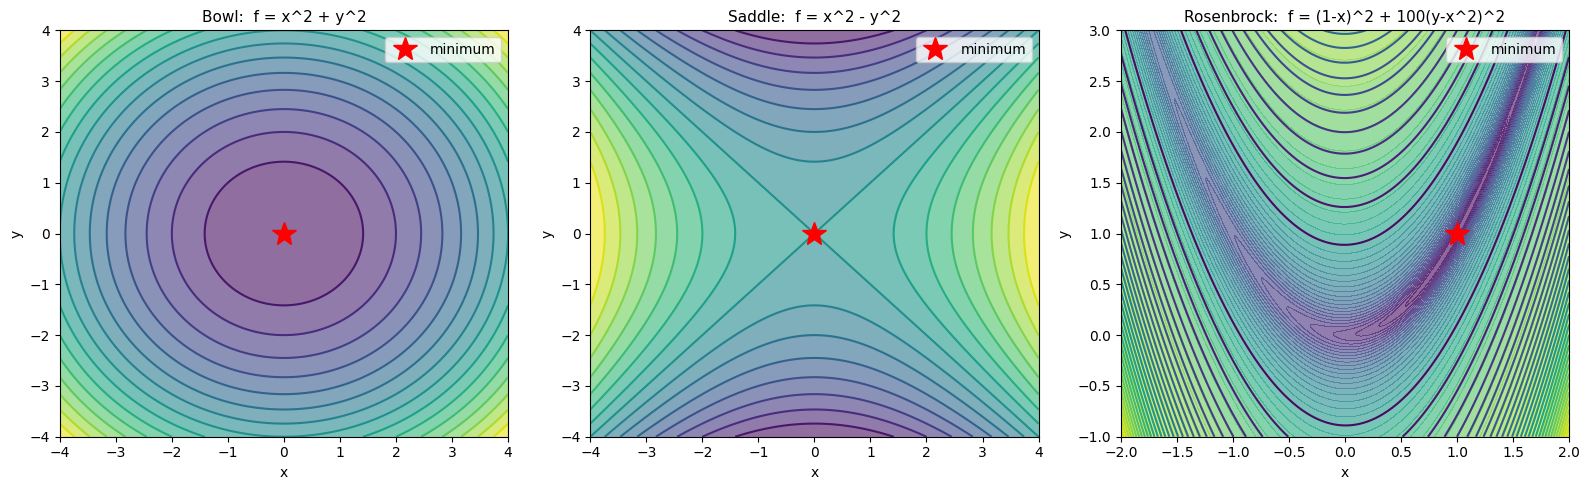

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

configs = [
    ("Bowl:  f = x^2 + y^2", bowl, np.linspace(-4, 4, 200), np.linspace(-4, 4, 200), (0, 0)),
    ("Saddle:  f = x^2 - y^2", saddle, np.linspace(-4, 4, 200), np.linspace(-4, 4, 200), (0, 0)),
    ("Rosenbrock:  f = (1-x)^2 + 100(y-x^2)^2", rosenbrock, np.linspace(-2, 2, 300), np.linspace(-1, 3, 300), (1, 1)),
]

for ax, (title, func, xs, ys, (mx, my)) in zip(axes, configs):
    X, Y = np.meshgrid(xs, ys)
    Z = func(X, Y)
    if "Rosen" in title:
        ax.contourf(X, Y, np.log1p(Z), levels=40, cmap="viridis", alpha=0.6)
        ax.contour(X, Y, Z, levels=40, cmap="viridis")
    else:
        ax.contourf(X, Y, Z, levels=20, cmap="viridis", alpha=0.6)
        ax.contour(X, Y, Z, levels=20, cmap="viridis")
    ax.plot(mx, my, "r*", markersize=18, label="minimum")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend()

plt.tight_layout()
plt.show()


## 3. Optimizers

Starting with plain gradient descent (SGD). Momentum, RMSProp, and Adam will be
added here in the same pattern as the project progresses.


In [4]:
def sgd(grad_fn, start, lr=0.1, steps=50):
    pos = np.array(start, dtype=float)
    path = [pos.copy()]
    for _ in range(steps):
        g = grad_fn(pos[0], pos[1])
        pos = pos - lr * g
        path.append(pos.copy())
    return np.array(path)

# quick check against hand-calculated steps
path = sgd(bowl_grad, start=(3, 4), lr=0.1, steps=5)
for i, p in enumerate(path):
    print(f"step {i}: ({p[0]:.3f}, {p[1]:.3f})")


step 0: (3.000, 4.000)
step 1: (2.400, 3.200)
step 2: (1.920, 2.560)
step 3: (1.536, 2.048)
step 4: (1.229, 1.638)
step 5: (0.983, 1.311)


### Visualize SGD trajectory on the Bowl

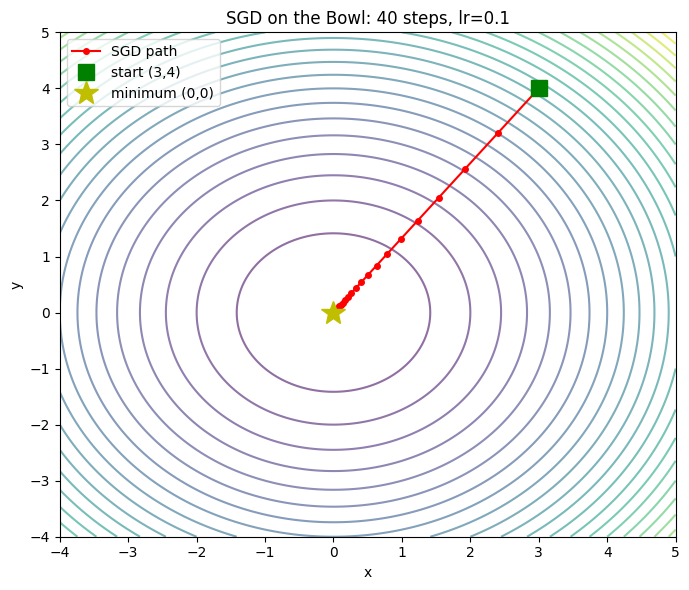

Final position: [0.00039877 0.00053169]


In [5]:
path = sgd(bowl_grad, start=(3, 4), lr=0.1, steps=40)

xs = np.linspace(-4, 5, 200)
ys = np.linspace(-4, 5, 200)
X, Y = np.meshgrid(xs, ys)
Z = bowl(X, Y)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(X, Y, Z, levels=25, cmap="viridis", alpha=0.6)
ax.plot(path[:, 0], path[:, 1], "o-", color="red", markersize=4, linewidth=1.5, label="SGD path")
ax.plot(path[0, 0], path[0, 1], "gs", markersize=12, label="start (3,4)")
ax.plot(0, 0, "y*", markersize=18, label="minimum (0,0)")
ax.set_title("SGD on the Bowl: 40 steps, lr=0.1")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend()
plt.tight_layout()
plt.show()

print("Final position:", path[-1])


### Momentum

v_new = beta * v_old + (1 - beta) * gradient
x_new = x_old - lr * v_new


In [6]:
def momentum(grad_fn, start, lr=0.1, beta=0.9, steps=50):
    pos = np.array(start, dtype=float)
    velocity = np.zeros_like(pos)
    path = [pos.copy()]
    for _ in range(steps):
        g = grad_fn(pos[0], pos[1])
        velocity = beta * velocity + (1 - beta) * g
        pos = pos - lr * velocity
        path.append(pos.copy())
    return np.array(path)


### RMSProp

s_new = beta * s_old + (1 - beta) * gradient^2
x_new = x_old - lr * gradient / (sqrt(s_new) + eps)


In [7]:
def rmsprop(grad_fn, start, lr=0.1, beta=0.9, eps=1e-8, steps=50):
    pos = np.array(start, dtype=float)
    sq_avg = np.zeros_like(pos)
    path = [pos.copy()]
    for _ in range(steps):
        g = grad_fn(pos[0], pos[1])
        sq_avg = beta * sq_avg + (1 - beta) * (g ** 2)
        pos = pos - lr * g / (np.sqrt(sq_avg) + eps)
        path.append(pos.copy())
    return np.array(path)


### Adam

Combines momentum (m) and RMSProp (v), with bias correction for early steps.


In [8]:
def adam(grad_fn, start, lr=0.1, beta1=0.9, beta2=0.999, eps=1e-8, steps=50):
    pos = np.array(start, dtype=float)
    m = np.zeros_like(pos)
    v = np.zeros_like(pos)
    path = [pos.copy()]
    for t in range(1, steps + 1):
        g = grad_fn(pos[0], pos[1])
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * (g ** 2)
        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)
        pos = pos - lr * m_hat / (np.sqrt(v_hat) + eps)
        path.append(pos.copy())
    return np.array(path)


## 4. Comparing All 4 Optimizers: Bowl vs Saddle

The saddle point is the real test — this is where adaptive methods (RMSProp, Adam)
should escape faster than plain SGD, per the literature review.


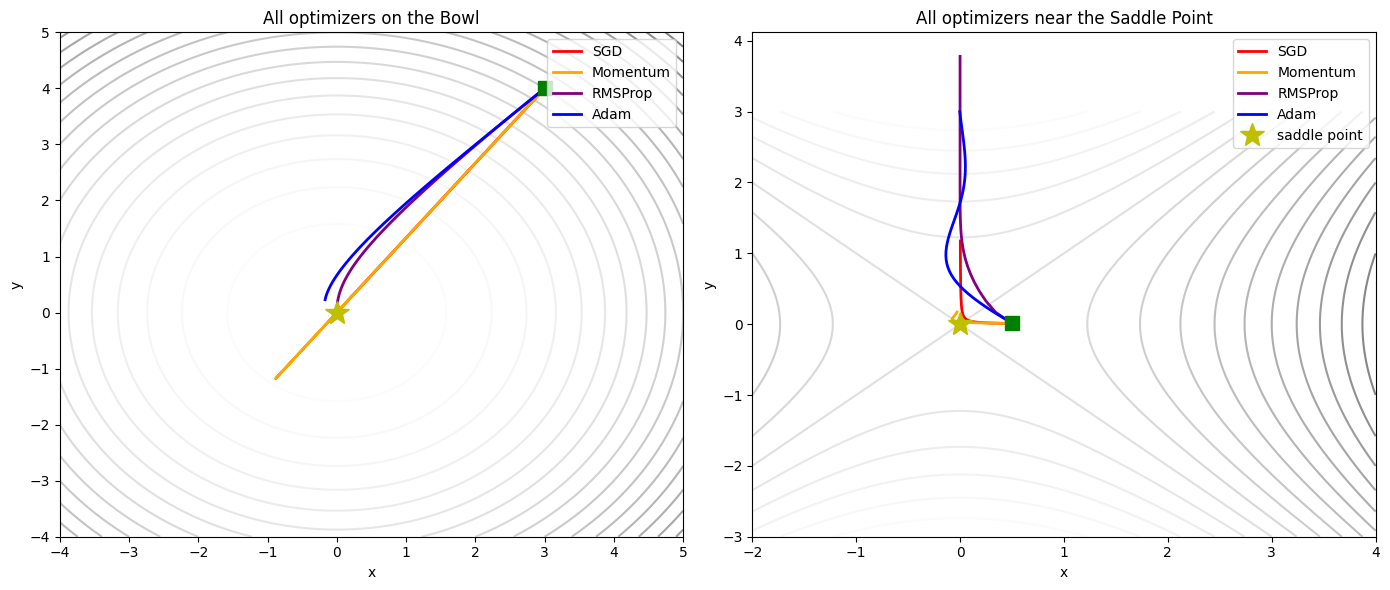

--- Saddle: distance from origin after 50 steps ---
  SGD        final distance: 1.1739
  Momentum   final distance: 0.1747
  RMSProp    final distance: 3.7802
  Adam       final distance: 2.9996


In [9]:
OPTIMIZERS = [
    ("SGD", sgd, "red"),
    ("Momentum", momentum, "orange"),
    ("RMSProp", rmsprop, "purple"),
    ("Adam", adam, "blue"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bowl
ax = axes[0]
xs = np.linspace(-4, 5, 200); ys = np.linspace(-4, 5, 200)
X, Y = np.meshgrid(xs, ys); Z = bowl(X, Y)
ax.contour(X, Y, Z, levels=20, cmap="Greys", alpha=0.5)
for name, fn, color in OPTIMIZERS:
    path = fn(bowl_grad, start=(3, 4), lr=0.1, steps=50)
    ax.plot(path[:, 0], path[:, 1], "-", color=color, linewidth=2, label=name)
ax.plot(3, 4, "gs", markersize=10)
ax.plot(0, 0, "y*", markersize=18)
ax.set_title("All optimizers on the Bowl")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend()

# Saddle
ax = axes[1]
xs = np.linspace(-2, 4, 200); ys = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(xs, ys); Z = saddle(X, Y)
ax.contour(X, Y, Z, levels=20, cmap="Greys", alpha=0.5)
for name, fn, color in OPTIMIZERS:
    path = fn(saddle_grad, start=(0.5, 0.01), lr=0.05, steps=50)
    ax.plot(path[:, 0], path[:, 1], "-", color=color, linewidth=2, label=name)
ax.plot(0.5, 0.01, "gs", markersize=10)
ax.plot(0, 0, "y*", markersize=18, label="saddle point")
ax.set_title("All optimizers near the Saddle Point")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend()

plt.tight_layout()
plt.show()

print("--- Saddle: distance from origin after 50 steps ---")
for name, fn, color in OPTIMIZERS:
    path = fn(saddle_grad, start=(0.5, 0.01), lr=0.05, steps=50)
    dist = np.linalg.norm(path[-1])
    print(f"  {name:10s} final distance: {dist:.4f}")


**Observation:** RMSProp and Adam escape the saddle point fastest (largest distance
from origin after 50 steps), matching the literature review's claim that adaptive
methods handle saddle points better than plain SGD. Momentum escapes slowest here,
since its velocity has to build up from zero and doesn't yet have direction/speed
during the critical early steps near the flat saddle region.

## Next up (to be added in upcoming sessions)
- Systematic sweep across multiple starting points and learning rates
- Rosenbrock surface trials for all optimizers
- Markov chain text generator (order-1/2/3)
- Stationary distribution + entropy analysis
